# RNN vs LSTM vs GRU — Can they keep going without real data?

The goal here is simple:

Train three models on a sine-like wave.  
Then ask them to **keep going on their own** — no real data, just their own predictions fed back in.

That's where the difference shows up.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [2]:
torch.manual_seed(0) # seeds initial weights of RNN/LSTM/GRU
np.random.seed(0)  # seeds noise added to sine wave

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using:', device)

Using: cuda


## The signal



In [3]:
#creating data
N  = 500
t  = np.linspace(0, 30 * np.pi, N) # time steps
y  = np.sin(t + np.cos(t)) + np.random.normal(0, 0.03, N) # signal
y  = y.astype(np.float32)

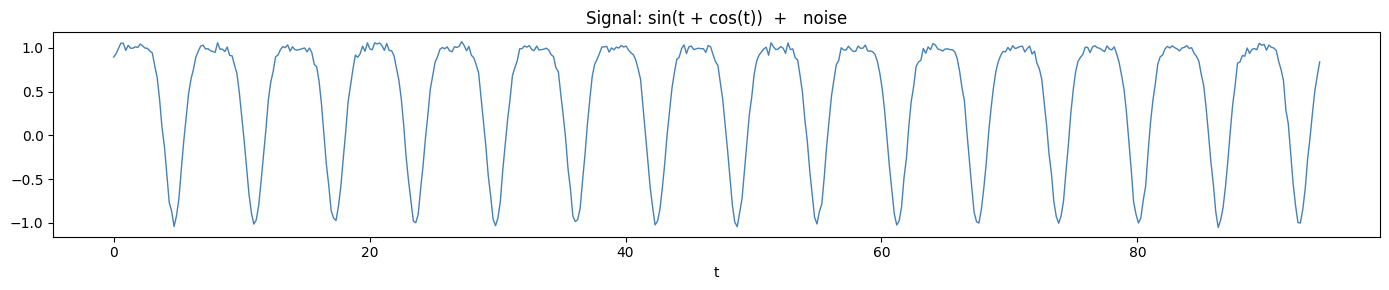

In [4]:
plt.figure(figsize=(14, 3))
plt.plot(t, y, color='steelblue', linewidth=1)
plt.title('Signal: sin(t + cos(t))  +   noise')
plt.xlabel('t')
plt.tight_layout()
plt.show()

## Sliding window

At each step the model sees the last **20 values** and predicts the **next one**.

In [5]:
SEQ = 20 # no. of past points model sees

X_all, y_all = [], []
for i in range(len(y) - SEQ): # sliding window over signal
    x_win = torch.tensor(y[i:i+SEQ]).unsqueeze(1).unsqueeze(1) #(20,) becomes (20, 1, 1) as rnn expects (seq length, batch size, input features)
    y_win = torch.tensor([y[i+SEQ]])
    X_all.append(x_win)
    y_all.append(y_win)

## Three models — identical setup

Same hidden size, same optimiser, same number of epochs.  
The **only** difference is the recurrent layer inside.

In [6]:
H = 12   # hidden state size, same for all three

class RNNNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(1, H, batch_first=False) # 1 is input feature, H → hidden state size
        # batch_first=false means input shape must be (seq_len, batch, input_size)
        self.fc  = nn.Linear(H, 1)
    def forward(self, x, h):
        out, h = self.rnn(x, h) # h carries past info
        return self.fc(out[-1]), h

rnn  = RNNNet().to(device)

In [7]:
class LSTMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, H, batch_first=False)
        self.fc   = nn.Linear(H, 1)
    def forward(self, x, h):
        out, h = self.lstm(x, h)
        return self.fc(out[-1]), h

lstm = LSTMNet().to(device)

In [8]:
class GRUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(1, H, batch_first=False)
        self.fc  = nn.Linear(H, 1)
    def forward(self, x, h):
        out, h = self.gru(x, h)
        return self.fc(out[-1]), h

gru  = GRUNet().to(device)

## Training

Same loop for all three. Nothing special here.

In [9]:
def train_model(model, is_lstm=False):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(50):
        model.train()
        h = None # initializing hidden state
        for xb, yb in zip(X_all, y_all): # Process one sequence at a time
            xb, yb = xb.to(device), yb.to(device)
            if h is not None:
                # Detach hidden state from previous computation graph
                h = (h[0].detach(), h[1].detach()) if is_lstm else h.detach()
                # as detach keep value and cuts the gradient and prevent its explosion
            opt.zero_grad()
            pred, h = model(xb, h)
            loss = loss_fn(pred.squeeze(), yb.squeeze())
            loss.backward() # compute gradients
            opt.step() # adjust weights

In [10]:
train_model(rnn)
train_model(lstm, is_lstm=True)
train_model(gru)

## Plot 1 — Short-term prediction

Each model predicts the next value given 20 real values as input.

All three models should look about the same here — this is the easy part.

In [11]:
def get_preds(model, is_lstm=False):
    model.eval()
    preds, truths = [], []
    h = None

    with torch.no_grad(): # turn off gradiennt tracking
        for xb, yb in zip(X_all, y_all): # zip combines two list element wise
            xb = xb.to(device)
            if h is not None:
                h = (h[0].detach(), h[1].detach()) if is_lstm else h.detach() # keeps memory
            pred, h = model(xb, h) # forward pass
            preds.append(pred.item()) # .item() Convert tensor → Python number
            truths.append(yb.item())
    return np.array(preds), np.array(truths) # covert to  numpy arrays for plotting

rnn_p, truth = get_preds(rnn)
lstm_p, _    = get_preds(lstm, is_lstm=True) #is_lstm: as lstm handle hidden state as (h,c) tuple
gru_p, _     = get_preds(gru) # and for rnn gru, normal h as hidden state

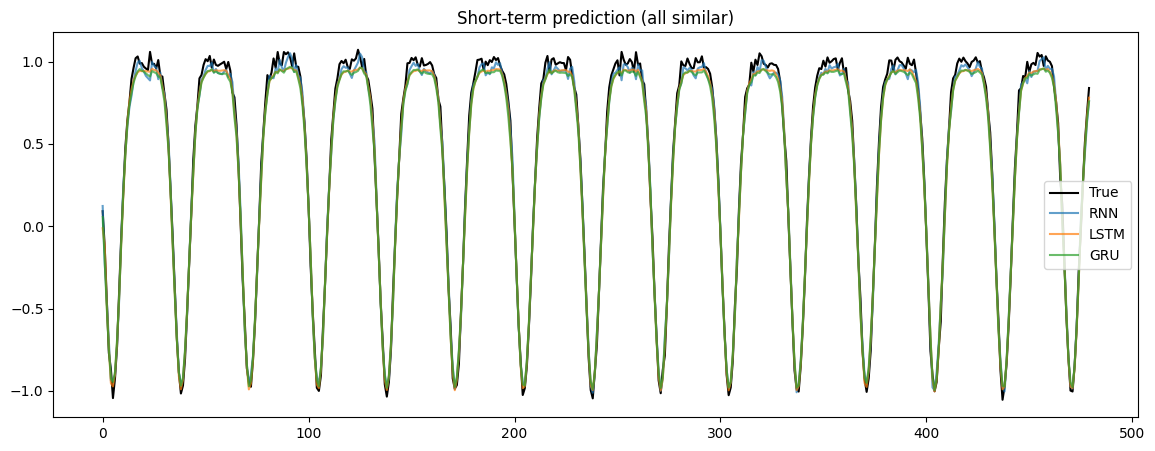

In [12]:
plt.figure(figsize=(14,5))
plt.plot(truth, label='True', color='black')
plt.plot(rnn_p, label='RNN', alpha=0.7)
plt.plot(lstm_p, label='LSTM', alpha=0.7)
plt.plot(gru_p, label='GRU', alpha=0.7) # alpha is opacity
plt.title("Short-term prediction (all similar)")
plt.legend()
plt.show()

## Plot 2 — Recursive extrapolation (the real test)

Give each model the last 20 real values as a starting point.  
Then let it run for **100 steps on its own** — each prediction becomes the next input.

> ⚠️ After the dashed line, the model is using its own predictions as input — no real data.

This is where the difference shows up.

In [13]:
def extrapolate(model, seed, is_lstm=False):
    model.eval()
    buf = list(seed.copy()) # strat with real data(last 20 pts)
    out = []
    h = None

    with torch.no_grad():
        for _ in range(100): # 100 future steps
            xb = torch.tensor(buf[-SEQ:], dtype=torch.float32) # xb takes last 20 elements
            xb = xb.unsqueeze(1).unsqueeze(1).to(device) # rnn input to device
            if h is not None:
                h = (h[0].detach(), h[1].detach()) if is_lstm else h.detach()
            pred, h = model(xb, h) # forward pass predict next value
            val = pred.item() # Tensor → number
            out.append(val)
            buf.append(val) # add prediction to sequence
    return np.array(out)

In [14]:
seed = y[-SEQ:] # here seed means initial data for pridiction

rnn_ext  = extrapolate(rnn, seed)
lstm_ext = extrapolate(lstm, seed, is_lstm=True)
gru_ext  = extrapolate(gru, seed)

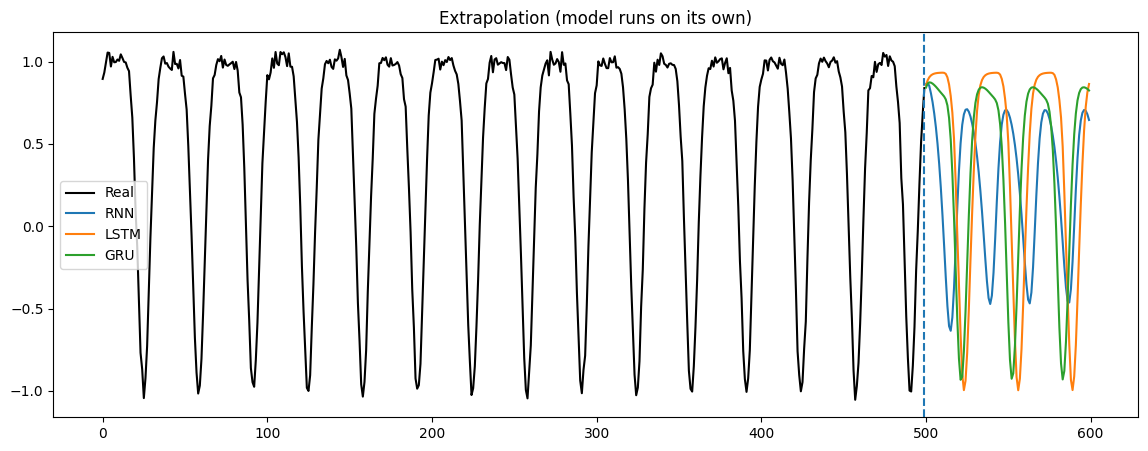

In [15]:
plt.figure(figsize=(14,5))
plt.plot(y, color='black', label='Real')
plt.axvline(len(y)-1, linestyle='--')
plt.plot(range(len(y), len(y)+100), rnn_ext, label='RNN')
plt.plot(range(len(y), len(y)+100), lstm_ext, label='LSTM')
plt.plot(range(len(y), len(y)+100), gru_ext, label='GRU')
plt.title("Extrapolation (model runs on its own)")
plt.legend()
plt.show()

## What just happened

**Short-term** — all three models look fine. They all learned the signal.

**Extrapolation** — the RNN loses the wave. The LSTM and GRU keep it going.

Why?

A plain RNN rewrites its memory at every step with no control over what gets kept or discarded.  
When it's running on its own outputs, small errors build up and the memory drifts to a flat line.

LSTM and GRU have **gates** — learned switches that decide what to remember and what to forget.  
That gives them a way to hold the wave's structure even without real data coming in.

The gate is the only difference. Everything else was identical.